I have succefully pulled and cleaned my air quality data from an open source API; which means it is now time to analyze the data and turn the insights into a dashsbaord that a client would pay money for.

The goal of the analysis is to: 	
    •	Identify pollution spikes
	•	Identify seasonal patterns
	•	Discuss possible emission sources
	•	Show exceedance alerts

I have pulled data from March 2016 - May 2017
I will be anlazying how PM2.5 changes in Saskatoon within that timeframe
I am intrested in spikes in PM2.5 and then hopefully explaining those spikes based on the time of year it is

In [1]:
# Import libraries
import pandas as pd
import geopandas as gpd 
import matplotlib.pyplot as plt

In [6]:
# import data
df = pd.read_csv("/Users/dawsonconlon/Coding/Python/GIS_API/data_cleaning/clean_measurements.csv")
print(df.head())

                    datetime pollutant  units  measurement   latitude  \
0  2016-03-10 07:00:00+00:00      pm25  µg/m³         10.0  52.136055   
1  2016-03-10 08:00:00+00:00      pm25  µg/m³          7.0  52.136055   
2  2016-03-11 15:00:00+00:00      pm25  µg/m³         20.0  52.136055   
3  2016-03-11 16:00:00+00:00      pm25  µg/m³          8.0  52.136055   
4  2016-03-11 17:00:00+00:00      pm25  µg/m³          4.0  52.136055   

    longitude  
0 -106.662796  
1 -106.662796  
2 -106.662796  
3 -106.662796  
4 -106.662796  


In [ ]:
def create_time_features(df):
    """
    Function to create time features from the datetime column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a datetime column.
    
    Returns:
    pandas.DataFrame: The input dataframe with new time features added.
    """
    
    #Convert datetime column to datetime format
    df["datetime"] = pd.to_datetime(df["datetime"])
    
    df["date"] = df["datetime"].dt.date
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df["days_of_week"] = df["datetime"].dt.day_name()
    
    return df


create_time_features(df)

,datetime,pollutant,units,measurement,latitude,longitude,date,year,month,day,hour,days_of_week
0,2016-03-10 07:00:00+00:00,pm25,µg/m³,10.0,52.136055,-106.662796,2016-03-10,2016,3,10,7,Thursday
1,2016-03-10 08:00:00+00:00,pm25,µg/m³,7.0,52.136055,-106.662796,2016-03-10,2016,3,10,8,Thursday
2,2016-03-11 15:00:00+00:00,pm25,µg/m³,20.0,52.136055,-106.662796,2016-03-11,2016,3,11,15,Friday
3,2016-03-11 16:00:00+00:00,pm25,µg/m³,8.0,52.136055,-106.662796,2016-03-11,2016,3,11,16,Friday
4,2016-03-11 17:00:00+00:00,pm25,µg/m³,4.0,52.136055,-106.662796,2016-03-11,2016,3,11,17,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2017-05-21 15:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,15,Sunday
996,2017-05-21 16:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,16,Sunday
997,2017-05-21 17:00:00+00:00,pm25,µg/m³,6.0,52.136055,-106.662796,2017-05-21,2017,5,21,17,Sunday
998,2017-05-21 18:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,18,Sunday


In [12]:
#calculate summary statistics for the value column
def summary_statistics(df):
    """
    Function to calculate summary statistics for the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column.
    
    Returns:
    pandas.DataFrame: A dataframe containing the summary statistics for the value column.
    """
    
    summary_stats = df["measurement"].describe()
    
    return summary_stats

summary_stats = summary_statistics(df)
print(summary_stats)

count    1000.000000
mean        6.252000
std         5.693585
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        51.000000
Name: measurement, dtype: float64


On average between March 2016 - May 2017 the PM2.5 in Saskatoon is 6.25 µg/m³

Envrio and CLimate Change Canada says 5-6 µg/m³ is a moderate risk, you would expect this for saskatoon urban areas

7-10 µg/m³ = High risk
Greater than or equal to 10 = Very high


I can also see there is a max day of 51 meaning there was a day that was extremaly high 

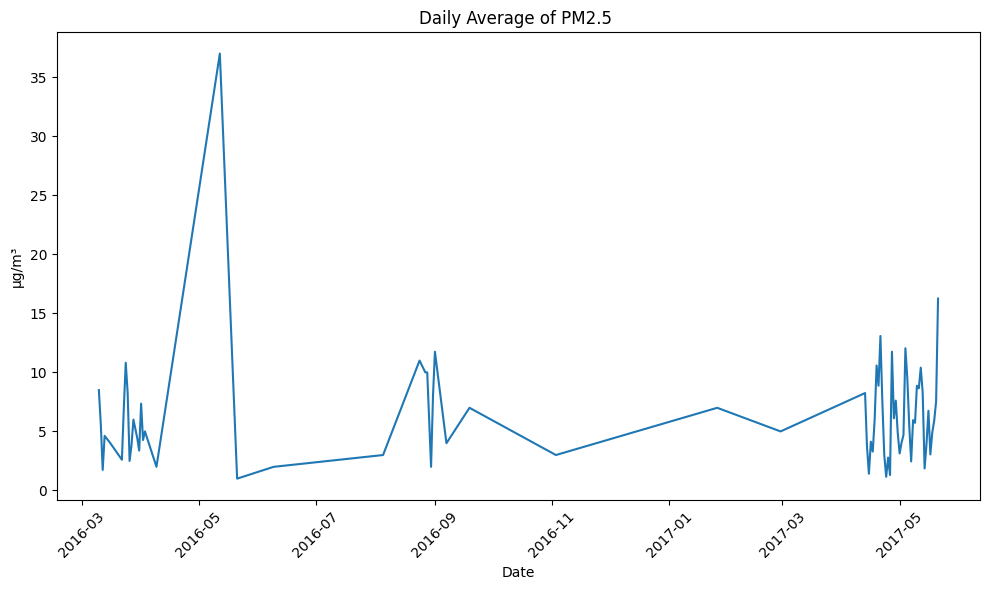

,date,measurement
0,2016-03-10,8.500000
1,2016-03-11,5.625000
2,2016-03-12,1.739130
3,2016-03-13,4.625000
4,2016-03-16,4.000000
...,...,...
67,2017-05-17,3.047619
68,2017-05-18,4.913043
69,2017-05-19,5.909091
70,2017-05-20,7.545455


In [ ]:
def daily_average(df):
    """
    Function to calculate the daily average of the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a date column.
    
    Returns:
    pandas.DataFrame: A dataframe containing the daily average of the value column.
    plots a line graph of the daily average over time.
    """
    
    daily_avg = df.groupby("date")["measurement"].mean().reset_index()
    
    #plot daily average
    plt.figure(figsize=(10,6))
    plt.plot(daily_avg["date"], daily_avg["measurement"])
    plt.xlabel("Date")
    plt.ylabel("µg/m³")
    plt.title("Daily Average of PM2.5 ")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return daily_avg

daily_average(df)

I see big spikes of ups and downs followed by spans of stability

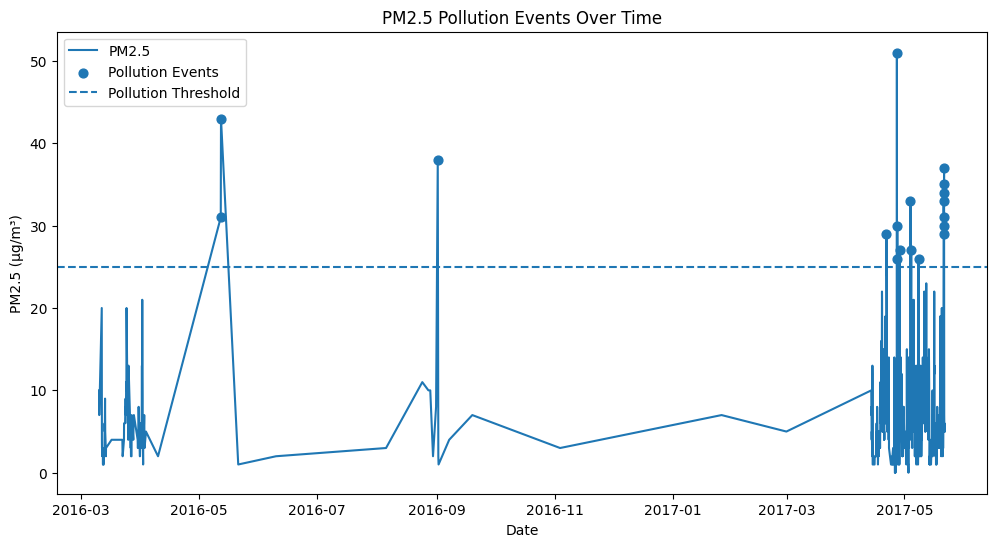

                     datetime pollutant  units  measurement   latitude  \
158 2016-05-12 05:00:00+00:00      pm25  µg/m³         31.0  52.136055   
159 2016-05-12 08:00:00+00:00      pm25  µg/m³         43.0  52.136055   
171 2016-09-01 12:00:00+00:00      pm25  µg/m³         38.0  52.136055   
366 2017-04-21 17:00:00+00:00      pm25  µg/m³         29.0  52.136055   
449 2017-04-27 01:00:00+00:00      pm25  µg/m³         26.0  52.136055   
450 2017-04-27 02:00:00+00:00      pm25  µg/m³         51.0  52.136055   
455 2017-04-27 07:00:00+00:00      pm25  µg/m³         30.0  52.136055   
474 2017-04-28 12:00:00+00:00      pm25  µg/m³         27.0  52.136055   
599 2017-05-04 03:00:00+00:00      pm25  µg/m³         33.0  52.136055   
607 2017-05-04 12:00:00+00:00      pm25  µg/m³         27.0  52.136055   
695 2017-05-08 07:00:00+00:00      pm25  µg/m³         26.0  52.136055   
986 2017-05-21 06:00:00+00:00      pm25  µg/m³         31.0  52.136055   
987 2017-05-21 07:00:00+00:00      pm2

In [ ]:
# detect pollutent events
def detect_pollutant_events(df, threshold = 25) :
    
    
    """
    Function to detect pollution events based on a specified threshold for the value column in the dataframe.
    
    Parameters:df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    
    Returns: pandas.DataFrame: A dataframe containing the pollution events that exceed the specified threshold.
    Plots a line graph of the value column over time, highlighting the pollution events that exceed
    
    """
    
    pollution_event = df[df["measurement"] > threshold]
    
    plt.figure(figsize=(12,6))

    plt.plot(df["datetime"], df["measurement"], label="PM2.5")

    plt.scatter(
        pollution_event["datetime"],
        pollution_event["measurement"],
        label="Pollution Events",
        s=40
    )

    plt.axhline(
        threshold,
        linestyle="--",
        label="Pollution Threshold"
    )

    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.title("PM2.5 Pollution Events Over Time")
    plt.legend()

    plt.show()
    
    return pollution_event

print(detect_pollutant_events(df))

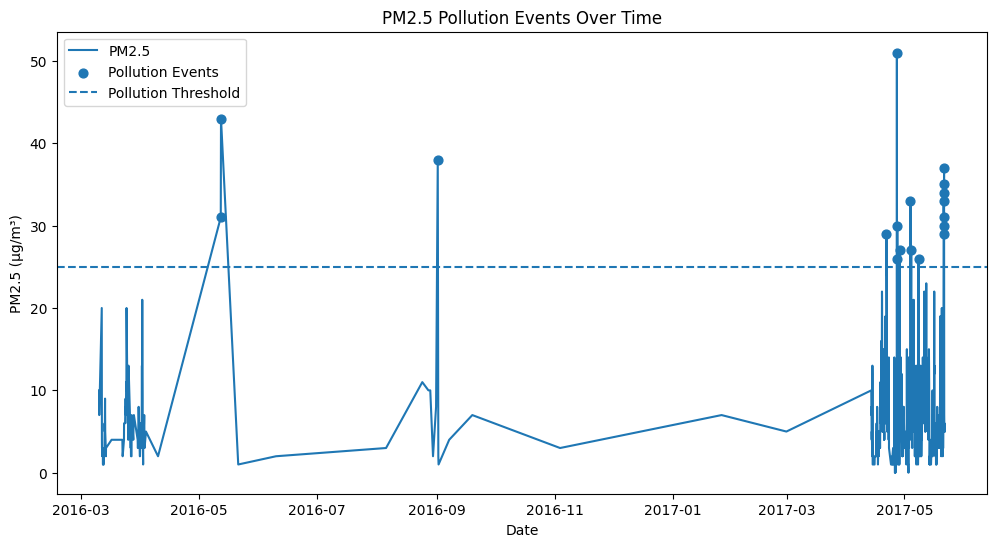

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_55341/151267865.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events["month"] = events["datetime"].dt.month


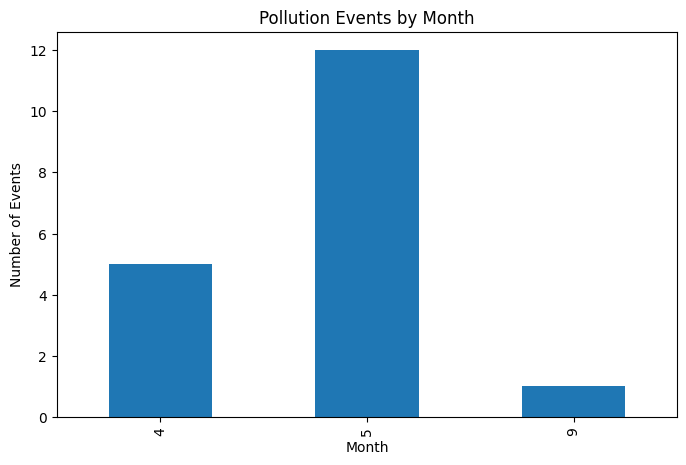

In [ ]:
def plot_monthly_events(df, threshold=25):
    
    
    """
    Function to plot the number of pollution events by month based on a specified threshold for the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    threshold (float): The threshold value for detecting pollution events. Default is 25.
    
    Returns:
    None: This function does not return any value but plots a bar graph of the number of pollution events by month.
    
    """

    events = detect_pollutant_events(df, threshold)

    events["month"] = events["datetime"].dt.month

    monthly_counts = events.groupby("month").size()

    plt.figure(figsize=(8,5))

    monthly_counts.plot(kind="bar")

    plt.title("Pollution Events by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Events")

    plt.show()
    
plot_monthly_events(df)

18 total majore polllution events and May and June account for nearly all of them

In [42]:
# How many total pollution events were detected?
print(f"Total pollution events detected: {total_events}")

Total pollution events detected: 18


In [ ]:

# monthly average
monthly_avg = df.groupby("month")["measurement"].mean()
print(monthly_avg)

month
1     7.000000
2     5.000000
3     5.062500
4     6.013228
5     6.715789
6     2.000000
8     7.333333
9     9.666667
11    3.000000
Name: measurement, dtype: float64


In [36]:

def detect_pollution_episodes(df, threshold=25):
    """
    Group consecutive pollution measurements into single events
    """

    df = df.sort_values("datetime").copy()

    df["is_event"] = df["measurement"] > threshold

    # create event groups whenever pollution status changes
    df["event_group"] = (df["is_event"] != df["is_event"].shift()).cumsum()

    # keep only pollution groups
    events = df[df["is_event"]]

    return events

In [ ]:
def calculate_event_durations(df, threshold=25):
    
    """
    Function to calculate the duration of pollution events based on a specified threshold for the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    threshold (float): The threshold value for detecting pollution events. Default is 25.

    Returns:
pandas.DataFrame: A dataframe containing the summary of pollution events, including start time, end time, maximum value, number of observations, and duration in hours for each event.

    
    """
    

    events = detect_pollution_episodes(df, threshold)

    event_summary = (
        events.groupby("event_group")
        .agg(
            start_time=("datetime", "min"),
            end_time=("datetime", "max"),
            max_pm25=("measurement", "max"),
            observations=("measurement", "count")
        )
        .reset_index(drop=True)
    )

    event_summary["duration_hours"] = (
        event_summary["end_time"] - event_summary["start_time"]
    ).dt.total_seconds() / 3600

    return event_summary

In [38]:
event_summary = calculate_event_durations(df)

average_duration = event_summary["duration_hours"].mean()

longest_event = event_summary["duration_hours"].max()

print("Average event duration:", average_duration, "hours")

print("Longest event:", longest_event, "hours")

Average event duration: 1.0 hours
Longest event: 6.0 hours


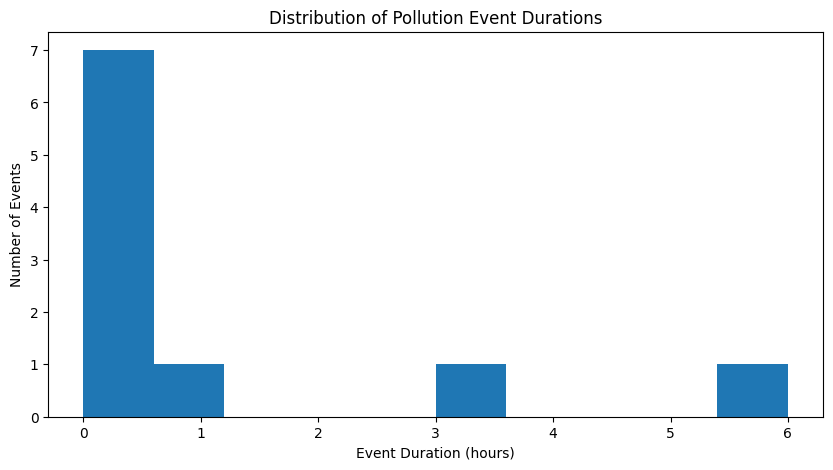

In [ ]:

def plot_event_durations(event_summary):
    
    """
    function to plot the distribution of pollution event durations based on the event summary dataframe.

    Parameters:
    event_summary (pandas.DataFrame): A dataframe containing the summary of pollution events, including duration

    Returns:
    None: This function does not return any value but plots a histogram of the distribution of pollution event durations

    """


    plt.figure(figsize=(10,5))

    plt.hist(event_summary["duration_hours"], bins=10)

    plt.xlabel("Event Duration (hours)")
    plt.ylabel("Number of Events")
    plt.title("Distribution of Pollution Event Durations")

    plt.show()
    
    plot_event_durations(event_summary)

On average these pollution evets are lasting less than a hour wiht the longest lasting 6 hours.